In [1]:
import numpy as np

In [2]:
F = np.array([
    [0,    0.26, 0.49, 0.31, 0.22, 0.49],  # Strong Hold
    [0.26, 0,   -0.18, 0.55, 0.38, 0.12],  # Smooth Surface
    [0.49,-0.18, 0,    0.15, 0.10, 0.33],  # Control Heat
    [0.31, 0.55, 0.15, 0,    0.44, 0.28],  # Min Deformation
    [0.22, 0.38, 0.10, 0.44, 0,    0.35],  # Proper Alignment
    [0.49, 0.12, 0.33, 0.28, 0.35, 0   ]   # Consistent Nugget
])

In [3]:
# Sigmoid transfer function
def sigmoid(x):
    return (2 / (1 + np.exp(-x))) - 1

In [4]:
# Input vector (E5 Misaligned weld scenario)
# Normalized from repertory grid: (score-4)/3
I = np.array([0, -0.33, 0.33, -0.33, -1.0, 0])

In [5]:
# FCM iteration
def run_fcm(input_vector, matrix, iterations=20, threshold=0.001):
    state = input_vector.copy()
    print("Initial state:", np.round(state, 3))
    
    for i in range(iterations):
        new_state = sigmoid(np.dot(state, matrix))
        
        # Check convergence
        if np.max(np.abs(new_state - state)) < threshold:
            print(f"Converged at iteration {i+1}")
            break
            
        state = new_state
        print(f"Iteration {i+1}: {np.round(state, 3)}")
    
    return state

In [6]:
# Run simulation
labels = ['Strong Hold','Smooth Surf',
          'Control Heat','Min Deform',
          'Prop Align','Consist Nugget']

result = run_fcm(I, F)

Initial state: [ 0.   -0.33  0.33 -0.33 -1.    0.  ]
Iteration 1: [-0.123 -0.301 -0.045 -0.278 -0.118 -0.184]
Iteration 2: [-0.15  -0.121 -0.06  -0.156 -0.165 -0.115]
Iteration 3: [-0.101 -0.095 -0.065 -0.113 -0.097 -0.104]
Iteration 4: [-0.082 -0.063 -0.047 -0.082 -0.075 -0.074]
Iteration 5: [-0.059 -0.048 -0.036 -0.06  -0.054 -0.056]
Iteration 6: [-0.044 -0.035 -0.027 -0.045 -0.04  -0.041]
Iteration 7: [-0.032 -0.026 -0.02  -0.033 -0.03  -0.031]
Iteration 8: [-0.024 -0.019 -0.015 -0.024 -0.022 -0.023]
Iteration 9: [-0.018 -0.014 -0.011 -0.018 -0.016 -0.017]
Iteration 10: [-0.013 -0.01  -0.008 -0.013 -0.012 -0.012]
Iteration 11: [-0.01  -0.008 -0.006 -0.01  -0.009 -0.009]
Iteration 12: [-0.007 -0.006 -0.004 -0.007 -0.007 -0.007]
Iteration 13: [-0.005 -0.004 -0.003 -0.005 -0.005 -0.005]
Iteration 14: [-0.004 -0.003 -0.002 -0.004 -0.004 -0.004]
Iteration 15: [-0.003 -0.002 -0.002 -0.003 -0.003 -0.003]
Converged at iteration 16


In [7]:
print("\n=== FINAL RESULT ===")
for label, value in zip(labels, result):
    status = "GOOD" if value > 0.3 else "WARNING" if value > 0 else "CRITICAL"
    print(f"{label:20s}: {value:+.3f} → {status}")


=== FINAL RESULT ===
Strong Hold         : -0.003 → CRITICAL
Smooth Surf         : -0.002 → CRITICAL
Control Heat        : -0.002 → CRITICAL
Min Deform          : -0.003 → CRITICAL
Prop Align          : -0.003 → CRITICAL
Consist Nugget      : -0.003 → CRITICAL


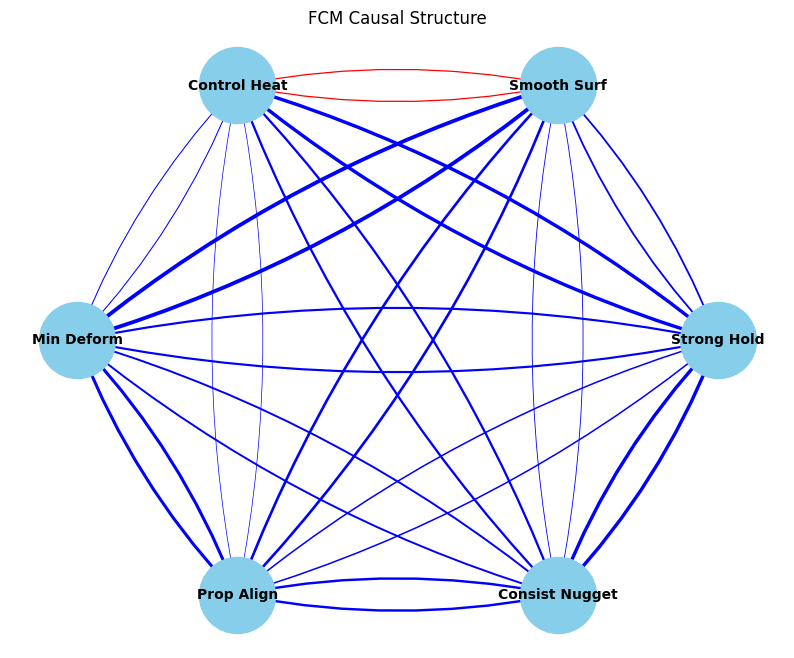

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# Using your labels and matrix F
G = nx.DiGraph()

# Add edges based on weights in F
for i in range(len(labels)):
    for j in range(len(labels)):
        weight = F[i][j]
        if weight != 0:
            G.add_edge(labels[i], labels[j], weight=weight)

# Layout and Drawing
plt.figure(figsize=(10, 8))
pos = nx.circular_layout(G)  # Circular layout works best for FCMs

# Color edges: Blue for positive influence, Red for negative
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_colors = ['blue' if w > 0 else 'red' for w in weights]
widths = [abs(w) * 5 for w in weights] # Scale width by weight

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=widths, edge_color=edge_colors, 
                       arrowstyle='-|>', arrowsize=20, connectionstyle='arc3,rad=0.1')

plt.title("FCM Causal Structure")
plt.axis('off')
plt.show()

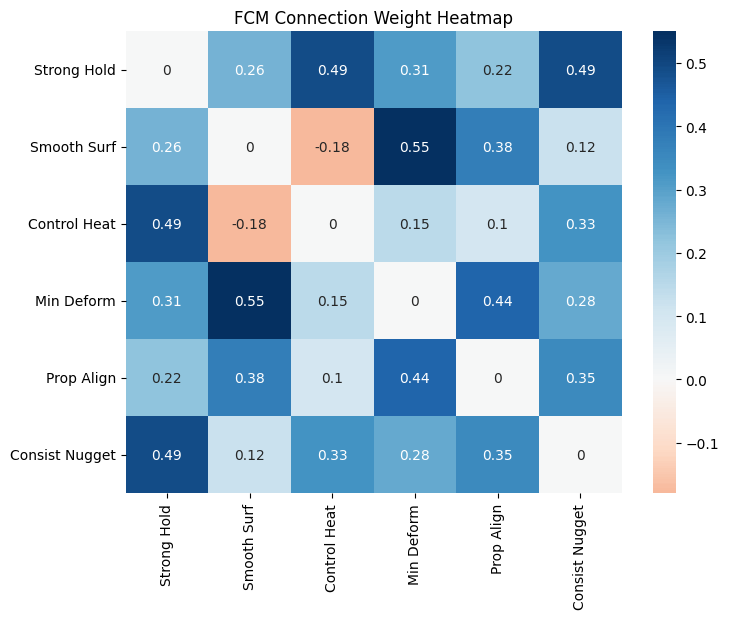

In [10]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(F, annot=True, xticklabels=labels, yticklabels=labels, cmap='RdBu', center=0)
plt.title("FCM Connection Weight Heatmap")
plt.show()